In [ ]:
import sys
import subprocess

try:
    from easypip import easyimport
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "easypip"], check=True)
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup(maze_mdp=True)

import os
from pathlib import Path
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
import gymnasium as gym
from omegaconf import OmegaConf
import bbrl_gymnasium

import time
from datetime import timedelta

[easypip] Installing swig


In [ ]:
def make_mdp_env(width, height, ratio, render_mode="rgb_array"):
    mdp = gym.make(
        "MazeMDP-v0",
        render_mode=render_mode,
        kwargs={"width": width, "height": height, "ratio": ratio},
    )
    env = mdp.unwrapped  # MDP sans TimeLimitWrapper
    return mdp, env

In [ ]:
PARAMS = {
    "width": 5,
    "height": 5,
    "ratio": 0.2,
    "nb_episodes": 200,
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon": 0.3,
    "epsilon_decay": 0.99, #taux de décroissance de epsilon après chaque épisode.
    "nb_repeats": 5,
    "alpha_actor": 0.01

}

In [ ]:
mdp, env = make_mdp_env(PARAMS["width"], PARAMS["height"], PARAMS["ratio"])
nb_states = env.observation_space.n
nb_actions = env.action_space.n

In [ ]:
# def choose_action(q_values, epsilon, state):
#     if np.random.random() < epsilon:
#         return np.random.randint(nb_actions)
#     return np.argmax(q_values[state])

In [ ]:
def choose_action(policy, state, temperature=1.0):
    preferences = policy[state] / temperature
    max_pref = np.max(preferences)
    exp_preferences = np.exp(preferences - max_pref)
    probs = exp_preferences / np.sum(exp_preferences)
    return np.random.choice(len(probs), p=probs)

# def choose_action(q_values, epsilon, state, policy):
#     if np.random.rand() < epsilon:
#         action = np.random.randint(len(q_values[state]))
#     else:
#         renormalize(policy, state)
#         action = np.random.choice(len(policy[state]), p=policy[state])
#     return action

In [65]:
# def renormalize(policy, state):
#     total = policy[state].sum()
#     if total > 0:
#         policy[state] /= total
#     else:
#         policy[state] = np.ones_like(policy[state]) / len(policy[state])

def renormalize(policy, state, epsilon=1e-6):
    policy[state] = np.maximum(policy[state], epsilon)
    policy[state] /= policy[state].sum()

In [66]:
def sarsa_update(q_values, state, action, reward, next_state, next_action, alpha, gamma, terminated):
    current_q = q_values[state, action]
    next_q = 0 if terminated else q_values[next_state, next_action]
    td_error = reward + gamma * next_q - current_q
    q_values[state, action] = current_q + alpha * td_error
    return td_error


def q_learning_max_update(q_values, state, action, reward, next_state, alpha, gamma, terminated):
    current_max = q_values[state].max()
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - current_max
    q_values[state, action] += alpha * td_error
    return td_error


def mean_sarsa_update(q_values, state, action, reward, next_state, policy, alpha, gamma, terminated):
    baseline = (policy[state] * q_values[state]).sum()
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - baseline
    q_values[state, action] += alpha * td_error
    return td_error


def standard_q_learning_update(q_values, state, action, reward, next_state, alpha, gamma, terminated):
    current_q = q_values[state, action]
    next_max = 0 if terminated else q_values[next_state].max()
    td_error = reward + gamma * next_max - current_q
    q_values[state, action] = current_q + alpha * td_error
    return td_error

# def update_policy(policy, q_values, state, action, td_error, alpha_actor):
#     # maj uniquement de l'action actuelle
#     policy[state, action] += alpha_actor * td_error
#     policy[state, action] = max(policy[state, action], 1e-8)

#     policy[state] /= policy[state].sum()
#     #np.linalg.norm(q_values)
#     return policy

def update_policy(policy, state, action, td_error, alpha_actor):
    preferences = policy[state]
    max_pref = np.max(preferences)
    exp_prefs = np.exp(preferences - max_pref)
    probs = exp_prefs / np.sum(exp_prefs)

    for a in range(len(probs)):
        grad_log = (1 if a == action else 0) - probs[a]
        policy[state, a] += alpha_actor * td_error * grad_log

    renormalize(policy, state)

    return policy



In [ ]:
# def run_episode(env, q_values, policy, alpha, gamma, epsilon, update_type, alpha_actor):
#     state, _ = env.reset()
#     done = False
#     steps = 0
#     total_reward = 0

#     while not done and steps < 500:
#         action = choose_action(q_values, epsilon, state)
#         next_state, reward, terminated, truncated, _ = env.step(action)
#         reward = reward - 0.01
#         next_action = choose_action(q_values, epsilon, next_state)

#         if update_type == 1:
#             td = sarsa_update(q_values, state, action, reward, next_state, next_action, alpha, gamma, terminated)
#         elif update_type == 2:
#             td = q_learning_max_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)
#         elif update_type == 3:
#             td = mean_sarsa_update(q_values, state, action, reward, next_state, policy, alpha, gamma, terminated)
#         else:
#             td = standard_q_learning_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)

#         policy = update_policy(policy, q_values, state, action, td, alpha_actor)

#         state = next_state
#         total_reward += reward
#         steps += 1
#         done = terminated or truncated

#     return steps, total_reward


In [53]:
def run_episode(env, q_values, policy, alpha, gamma, temperature, update_type, alpha_actor):
    state, _ = env.reset()
    done = False
    steps = 0
    total_reward = 0

    while not done and steps < 500:
        action = choose_action(policy, state, temperature)
        next_state, reward, terminated, truncated, _ = env.step(action)
        reward = reward - 0.01
        next_action = choose_action(policy, next_state, temperature)

        if update_type == 1:
            td = sarsa_update(q_values, state, action, reward, next_state, next_action, alpha, gamma, terminated)
        elif update_type == 2:
            td = q_learning_max_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)
        elif update_type == 3:
            td = mean_sarsa_update(q_values, state, action, reward, next_state, policy, alpha, gamma, terminated)
        else:
            td = standard_q_learning_update(q_values, state, action, reward, next_state, alpha, gamma, terminated)

        policy = update_policy(policy, state, action, td, alpha_actor)

        state = next_state
        total_reward += reward
        steps += 1
        done = terminated or truncated

    return steps, total_reward

In [ ]:
# def run_actor_critic(env, update_type, nb_episodes, alpha, gamma, epsilon_init, epsilon_decay, nb_repeats, alpha_actor):
#     all_steps, all_rewards = [], []
#     for _ in range(nb_repeats):
#         q_values = np.zeros((nb_states, nb_actions))
#         policy = np.ones((nb_states, nb_actions)) / nb_actions
#         eps = epsilon_init
#         steps_hist, reward_hist = [], []
#         for _ in range(nb_episodes):
#             s, r = run_episode(env, q_values, policy, alpha, gamma, eps, update_type, alpha_actor)
#             steps_hist.append(s)
#             reward_hist.append(r)
#             eps *= epsilon_decay
#         all_steps.append(steps_hist)
#         all_rewards.append(reward_hist)
#     return np.array(all_steps), np.array(all_rewards)


In [54]:
def run_actor_critic(env, update_type, nb_episodes, alpha, gamma, temperature_init, temperature_decay, nb_repeats, alpha_actor):
    all_steps, all_rewards = [], []
    for _ in range(nb_repeats):
        q_values = np.zeros((nb_states, nb_actions))
        policy = np.ones((nb_states, nb_actions)) / nb_actions
        temperature = temperature_init
        steps_hist, reward_hist = [], []
        for _ in range(nb_episodes):
            s, r = run_episode(env, q_values, policy, alpha, gamma, temperature, update_type, alpha_actor)
            steps_hist.append(s)
            reward_hist.append(r)
            temperature *= temperature_decay
        all_steps.append(steps_hist)
        all_rewards.append(reward_hist)
    return np.array(all_steps), np.array(all_rewards)


In [55]:
def plot_metric(all_data, title, ylabel, smoothing=5):
    mean = all_data.mean(axis=0)
    std = all_data.std(axis=0)
    if smoothing > 1:
        kern = np.ones(smoothing) / smoothing
        mean = np.convolve(mean, kern, mode='valid')
        std = np.convolve(std, kern, mode='valid')
        x = np.arange(smoothing-1, len(mean)+smoothing-1)
    else:
        x = np.arange(len(mean))
    plt.figure(figsize=(8,5))
    plt.plot(x, mean, label='Mean')
    plt.fill_between(x, mean-std, mean+std, alpha=0.3)
    plt.title(f"{ylabel} par épisode - {title}")
    plt.xlabel('Épisode')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()


In [56]:
def plot_all_metrics(all_results, title, ylabel, smoothing=5):
    plt.figure(figsize=(10, 6))

    for i, (data, name) in enumerate(all_results):
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        if smoothing > 1:
            kern = np.ones(smoothing) / smoothing
            mean = np.convolve(mean, kern, mode='valid')
            std = np.convolve(std, kern, mode='valid')
            x = np.arange(smoothing-1, len(mean)+smoothing-1)
        else:
            x = np.arange(len(mean))

        plt.plot(x, mean, label=name)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(f"{ylabel} par épisode - {title}")
    plt.xlabel('Épisode')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()


Algorithm: SARSA
Algorithm: Q-learning (max)
Algorithm: Mean SARSA
Algorithm: Standard Q-learning


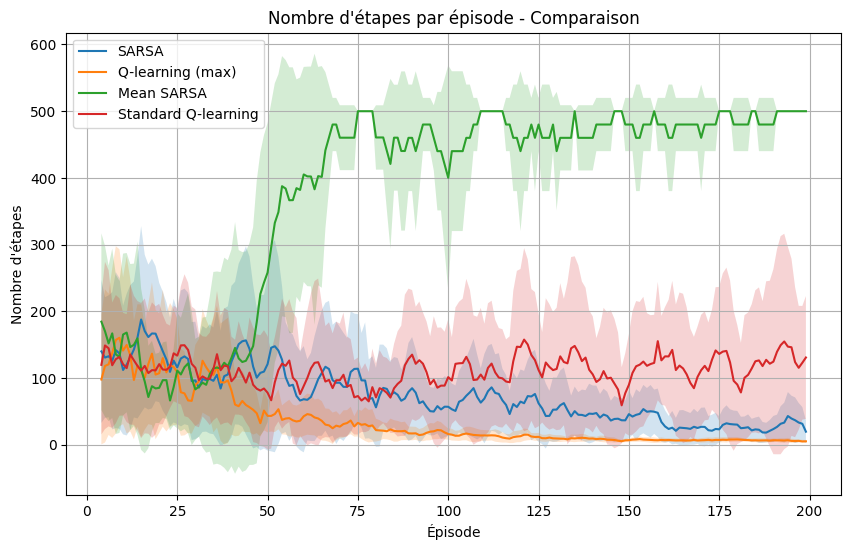

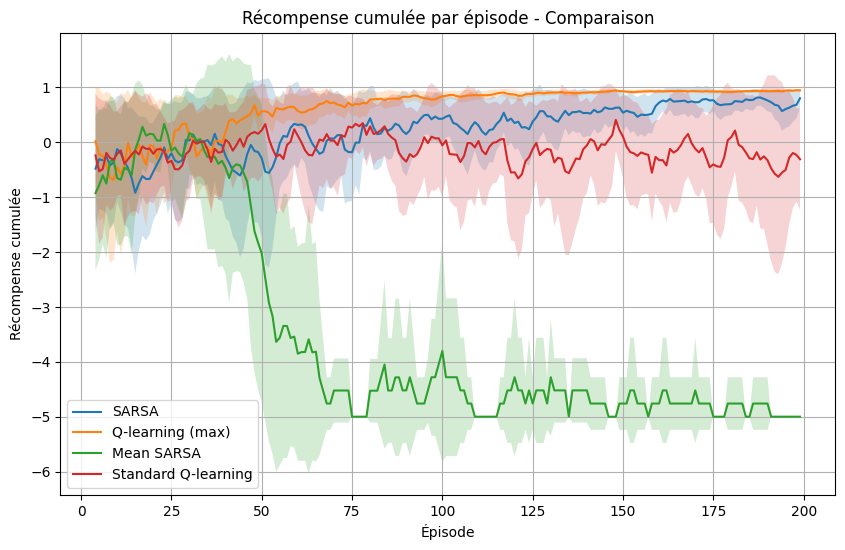

In [57]:
update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]
results = []

for u, name in enumerate(update_names, start=1):
    print(f"Algorithm: {name}")
    steps, rewards = run_actor_critic(
        env, u,
        PARAMS['nb_episodes'], PARAMS['alpha'], PARAMS['gamma'],
        PARAMS['epsilon'], PARAMS['epsilon_decay'], PARAMS['nb_repeats'],
        PARAMS['alpha_actor']
    )
    results.append(((steps, name), (rewards, name)))

plot_all_metrics([r[0] for r in results], title="Comparaison", ylabel="Nombre d'étapes")
plot_all_metrics([r[1] for r in results], title="Comparaison", ylabel="Récompense cumulée")


Running Actor-Critic...

Algorithm: SARSA


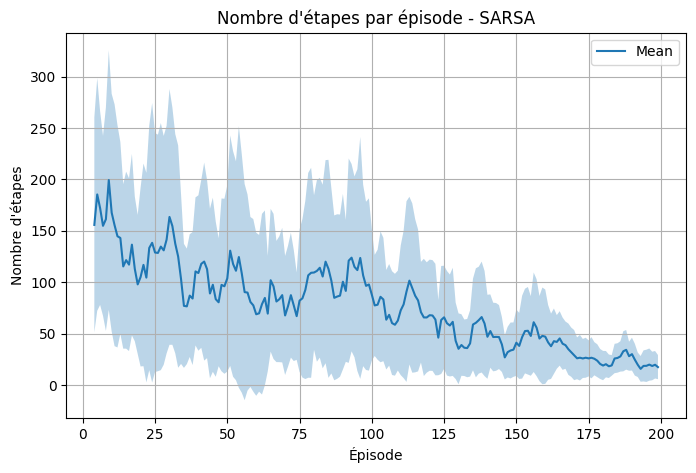

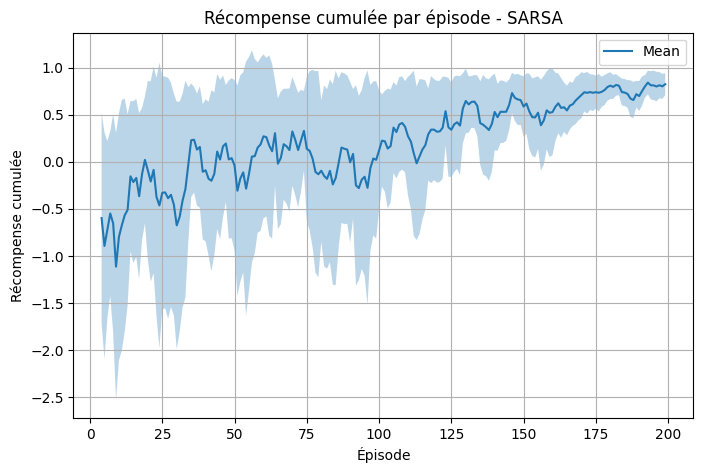

Algorithm: Q-learning (max)


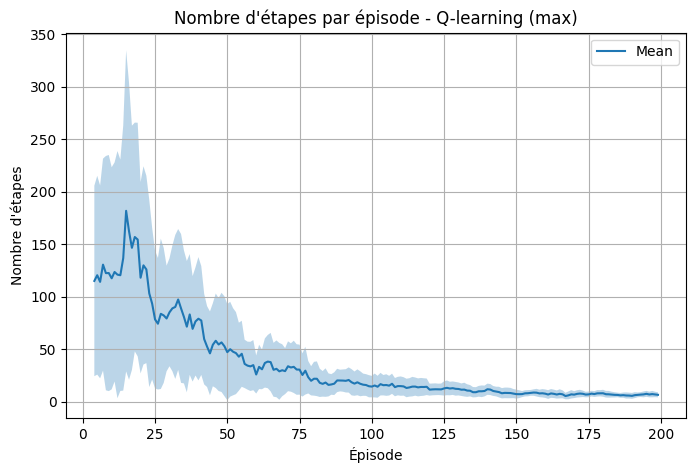

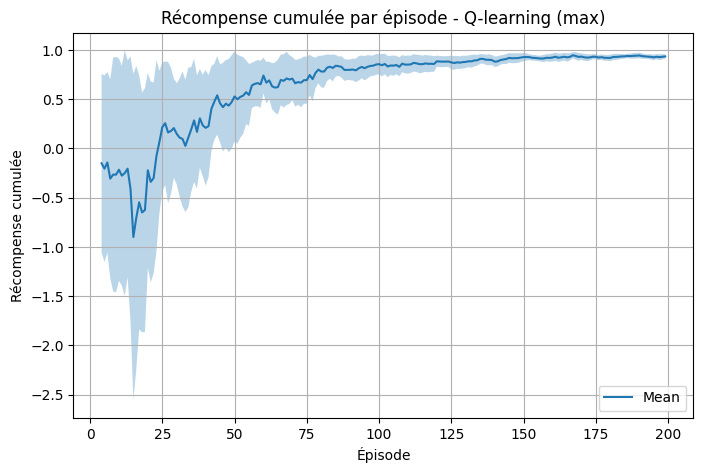

Algorithm: Mean SARSA


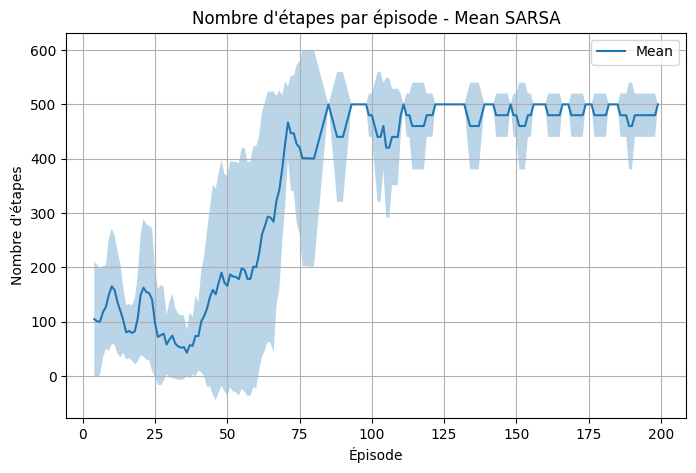

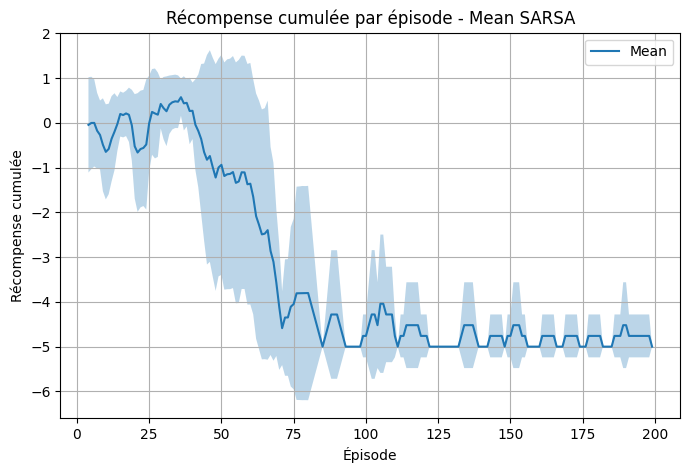

Algorithm: Standard Q-learning


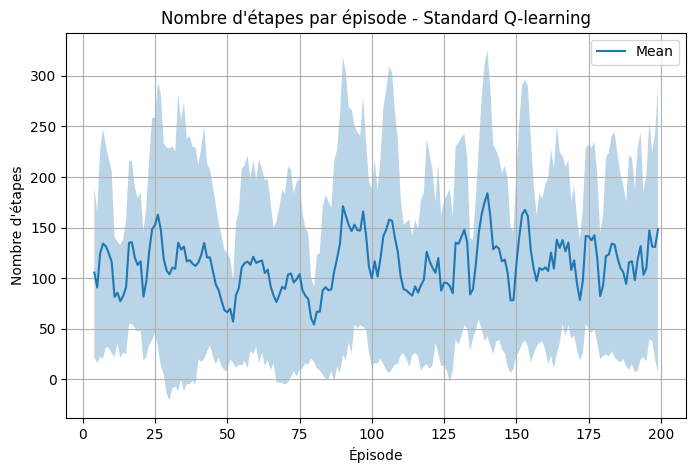

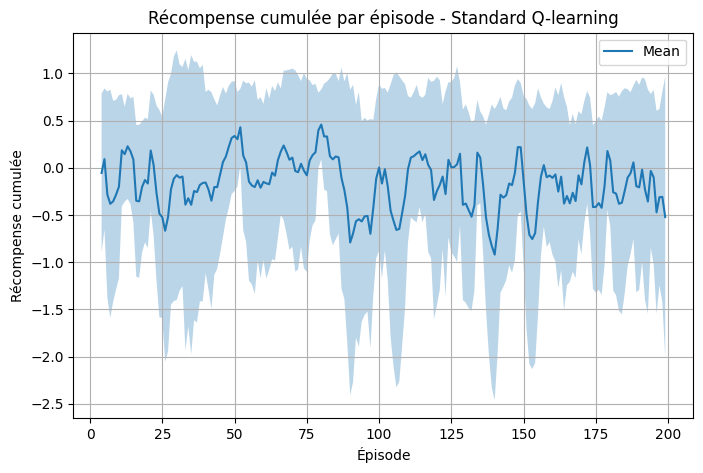

In [58]:
print("Running Actor-Critic...\n")
update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]
results = []

for u, name in enumerate(update_names, start=1):
    print(f"Algorithm: {name}")
    steps, rewards = run_actor_critic(
        env, u,
        PARAMS['nb_episodes'], PARAMS['alpha'], PARAMS['gamma'],
        PARAMS['epsilon'], PARAMS['epsilon_decay'], PARAMS['nb_repeats'],
        PARAMS['alpha_actor']
    )
    plot_metric(steps, name, 'Nombre d\'étapes')
    plot_metric(rewards, name, 'Récompense cumulée')
    results.append((steps, rewards))


In [62]:
agreement_percents = []

for u, name in enumerate(update_names, start=1):
    q_values = np.zeros((nb_states, nb_actions))
    policy   = np.ones((nb_states, nb_actions)) / nb_actions
    eps      = PARAMS['epsilon']

    visited_states = set()  # stocke les états rencontrés

    for _ in range(PARAMS['nb_episodes']):
        state = env.reset()[0]
        done = False
        while not done:
            action_probs = policy[state]
            action = np.random.choice(nb_actions, p=action_probs)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            visited_states.add(state)  # marque l'état comme visité
            state = next_state

        # Mise à jour (actor + critic)
        _, _ = run_episode(env, q_values, policy,
                           PARAMS['alpha'], PARAMS['gamma'],
                           eps, u, PARAMS['alpha_actor'])
        eps *= PARAMS['epsilon_decay']

    visited_states = list(visited_states)  # convertit en liste indexable

    actor_actions  = np.argmax(policy,   axis=1)
    critic_actions = np.argmax(q_values, axis=1)

    # comparaison seulement sur les états visités
    agreements = (actor_actions[visited_states] == critic_actions[visited_states])
    percent_agree = agreements.mean() * 100
    agreement_percents.append(percent_agree)

ValueError: probabilities are not non-negative

In [ ]:
plt.figure(figsize=(8, 4))
bars = plt.barh(update_names, agreement_percents, color=['#4C72B0','#55A868','#C44E52','#8172B3'])

plt.xlim(0, 100)
plt.xlabel("Taux d'accord (%)")
plt.title("Accord Acteur–Critique par algorithme")
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, pct in zip(bars, agreement_percents):
    plt.text(pct + 1, bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# TAUX SUR LES STEPS FAIT POUR UNE MAJ DONNEE :

agreement_percents = []

for u, name in enumerate(update_names, start=1):
    q_values = np.zeros((nb_states, nb_actions))
    policy   = np.ones((nb_states, nb_actions)) / nb_actions
    eps      = PARAMS['epsilon']

    total_steps = 0
    agreements = 0  # nombre de fois où actor et critic choisissent la même action

    for _ in range(PARAMS['nb_episodes']):
        state = env.reset()[0]
        done = False

        while not done:
            # Action choisie par la politique (acteur)
            action_probs = policy[state]
            actor_action = np.random.choice(nb_actions, p=action_probs)

            # Action préférée du critique (Q-table)
            critic_action = np.argmax(q_values[state])

            # Vérifie s'ils sont d'accord à ce step
            if actor_action == critic_action:
                agreements += 1
            total_steps += 1

            # Exécution de l'action
            next_state, reward, terminated, truncated, _ = env.step(actor_action)
            done = terminated or truncated
            state = next_state

        # Mise à jour de la Q-table et de la politique
        _, _ = run_episode(env, q_values, policy,
                           PARAMS['alpha'], PARAMS['gamma'],
                           eps, u, PARAMS['alpha_actor'])
        eps *= PARAMS['epsilon_decay']

    # Taux d'accord pondéré par step
    percent_agree = (agreements / total_steps) * 100
    agreement_percents.append(percent_agree)

In [ ]:
plt.figure(figsize=(8, 4))
bars = plt.barh(update_names, agreement_percents, color=['#4C72B0','#55A868','#C44E52','#8172B3'])

plt.xlim(0, 100)
plt.xlabel("Taux d'accord (%)")
plt.title("Accord Acteur–Critique par algorithme")
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, pct in zip(bars, agreement_percents):
    plt.text(pct + 1, bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:

import seaborn as sns

update_types = [1, 2, 3, 4]
update_names = ["SARSA", "Q-learning (max)", "Mean SARSA", "Standard Q-learning"]

alpha_actor = 0.1
alphas   = [0.01, 0.05, 0.1, 0.2]
epsilons = [0.1, 0.3, 0.5, 0.7]
gamma    = PARAMS['gamma']
decay    = PARAMS['epsilon_decay']
nb_eps   = PARAMS['nb_episodes']
nb_rep   = PARAMS['nb_repeats']

for u, name in zip(update_types, update_names):
    heatmap = np.zeros((len(alphas), len(epsilons)))
    for i, alpha in enumerate(alphas):
        for j, eps0 in enumerate(epsilons):
            _, rewards = run_actor_critic(
                env, u,
                nb_episodes=nb_eps,
                alpha=alpha,
                gamma=gamma,
                epsilon_init=eps0,
                epsilon_decay=decay,
                nb_repeats=nb_rep,
                alpha_actor=alpha_actor
            )
            heatmap[i, j] = rewards[:, -10:].mean()
    plt.figure(figsize=(5,4))
    sns.heatmap(
        heatmap,
        xticklabels=epsilons,
        yticklabels=alphas,
        annot=True,
        fmt=".2f",
        cmap="viridis"
    )
    plt.xlabel("epsilon init")
    plt.ylabel("alpha critic")
    plt.title(f"{name}\nRécompense moyenne (derniers 10 eps)")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

methods = {1:"SARSA",2:"Q-max",3:"Mean SARSA",4:"Q-std"}
threshold = 0.8
efficiencies = []

for u,name in methods.items():
    _, rewards = run_actor_critic(
        env, u,
        nb_episodes=PARAMS['nb_episodes'],
        alpha=PARAMS['alpha'],
        gamma=PARAMS['gamma'],
        epsilon_init=PARAMS['epsilon'],
        epsilon_decay=PARAMS['epsilon_decay'],
        nb_repeats=PARAMS['nb_repeats'],
        alpha_actor = PARAMS['alpha_actor']
    )
    mean_rew = rewards.mean(axis=0)
    T = next((i for i in range(len(mean_rew)-9)
              if mean_rew[i:i+10].mean() >= threshold),
             PARAMS['nb_episodes'])
    efficiencies.append(T)

plt.figure(figsize=(6,4))
plt.bar(list(methods.values()), efficiencies, color=['blue','green','red','purple'])
plt.ylabel("Épisodes pour atteindre 80% de récompense max")
plt.title("Sample Efficiency (seuil récompense)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import scipy.stats as st

entropies = {u: [] for u in methods}
for u in methods:
    q = np.zeros((nb_states, nb_actions))
    π = np.ones((nb_states, nb_actions)) / nb_actions
    eps = PARAMS['epsilon']
    for _ in range(PARAMS['nb_episodes']):
        _, _ = run_episode(env, q, π,
                           PARAMS['alpha'], PARAMS['gamma'],
                           eps, u, PARAMS['alpha_actor'])
        eps *= PARAMS['epsilon_decay']
        entropies[u].append(
            np.mean([st.entropy(π[s]) for s in range(nb_states)])
        )

window = 10
plt.figure(figsize=(10, 6))
for u, name in methods.items():
    vals = np.array(entropies[u])
    kern = np.ones(window) / window
    smooth = np.convolve(vals, kern, mode='valid')
    x = np.arange(window - 1, PARAMS['nb_episodes'])
    plt.plot(x, smooth, label=name, linewidth=2)

plt.xlabel("Épisode", fontsize=14)
plt.ylabel("Entropie moyenne", fontsize=14)
plt.title("Évolution de l'exploration (entropie)", fontsize=16)  # titre sans mention du lissage
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


NameError: name 'methods' is not defined